In [1]:
import pandas as pd

df = pd.read_csv("Parkinson_Dataset.csv")

print(df.shape)
print(df.head())

(34, 18)
   population_group_id population_group_name  measure_id measure_name  \
0                    1        All Population           5   Prevalence   
1                    1        All Population           5   Prevalence   
2                    1        All Population           5   Prevalence   
3                    1        All Population           5   Prevalence   
4                    1        All Population           5   Prevalence   

   location_id location_name  sex_id sex_name  age_id  age_name  cause_id  \
0          163         India       3     Both      22  All ages       544   
1          163         India       3     Both      22  All ages       544   
2          163         India       3     Both      22  All ages       544   
3          163         India       3     Both      22  All ages       544   
4          163         India       3     Both      22  All ages       544   

            cause_name  metric_id metric_name  year            val  \
0  Parkinson's dise

In [2]:
print(df["year"].min())
print(df["year"].max())
print(df["year"].nunique())

1990
2023
34


In [3]:
df[["year", "val", "lower", "upper"]].sort_values("year").head(10)

,year,val,lower,upper
1,1990,168732.600679,136626.659384,206975.444791
0,1991,178276.949692,143669.243716,217721.128660
3,1992,188353.316087,151758.187685,229149.644570
2,1993,199002.206561,161174.241106,241478.235422
5,1994,210147.870964,171019.401566,254787.891510
4,1995,221567.547816,181117.105245,268468.766828
6,1996,234259.911320,192160.846638,283350.575088
7,1997,248541.133965,204423.625558,300141.294750
8,1998,263874.746940,217418.591528,318208.961085
9,1999,279790.553130,230554.660833,336999.252271


In [4]:
# Create a clean forecasting dataframe

ts = df[["year", "val"]].copy()

# Sort by year
ts = ts.sort_values("year")

# Set year as the index
ts["year"] = pd.to_datetime(ts["year"], format="%Y")
ts = ts.set_index("year")

# Rename target column
ts = ts.rename(columns={"val": "Parkinson_cases"})

print(ts.head())
print(ts.tail())

            Parkinson_cases
year                       
1990-01-01    168732.600679
1991-01-01    178276.949692
1992-01-01    188353.316087
1993-01-01    199002.206561
1994-01-01    210147.870964
            Parkinson_cases
year                       
2019-01-01    658512.961156
2020-01-01    678887.414670
2021-01-01    710314.524012
2022-01-01    746950.297252
2023-01-01    778880.783031


In [5]:
print(ts.isnull().sum())

Parkinson_cases    0
dtype: int64


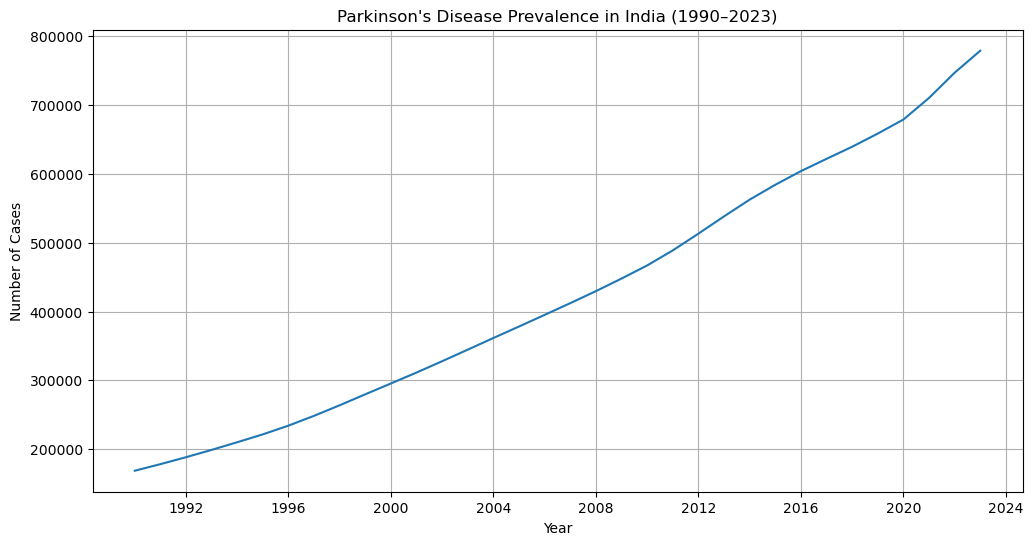

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(ts.index, ts["Parkinson_cases"])

plt.title("Parkinson's Disease Prevalence in India (1990–2023)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.grid(True)
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts["Parkinson_cases"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 2.1282752517281462
p-value: 0.9988181075066637


In [8]:
ts_diff = ts["Parkinson_cases"].diff().dropna()

print(ts_diff.head())

year
1991-01-01     9544.349014
1992-01-01    10076.366394
1993-01-01    10648.890475
1994-01-01    11145.664403
1995-01-01    11419.676852
Name: Parkinson_cases, dtype: float64


In [9]:
result_diff = adfuller(ts_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -0.6582746562013961
p-value: 0.8572634156450579


In [10]:
ts_diff2 = ts["Parkinson_cases"].diff().diff().dropna()

result_diff2 = adfuller(ts_diff2)

print("ADF Statistic:", result_diff2[0])
print("p-value:", result_diff2[1])

ADF Statistic: -2.8034446184718584
p-value: 0.05778341098582066


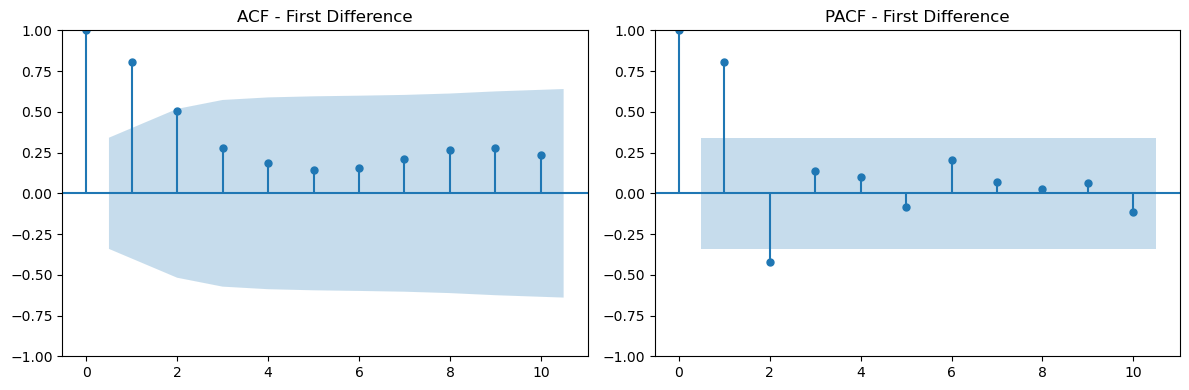

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(ts_diff, ax=ax[0], lags=10)
plot_pacf(ts_diff, ax=ax[1], lags=10)

ax[0].set_title("ACF - First Difference")
ax[1].set_title("PACF - First Difference")

plt.tight_layout()
plt.show()

In [12]:
train = ts.iloc[:-5]
test = ts.iloc[-5:]

print("Training period:", train.index.min().year, "to", train.index.max().year)
print("Testing period:", test.index.min().year, "to", test.index.max().year)

Training period: 1990 to 2018
Testing period: 2019 to 2023


In [13]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

orders = [
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1),
    (0, 1, 1)
]

results = []

for order in orders:
    model = ARIMA(train["Parkinson_cases"], order=order)
    fitted = model.fit()

    forecast = fitted.forecast(steps=len(test))

    mae = mean_absolute_error(test["Parkinson_cases"], forecast)
    rmse = np.sqrt(mean_squared_error(test["Parkinson_cases"], forecast))

    results.append({
        "Model": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("RMSE"))

C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.

            Model           MAE          RMSE
1  ARIMA(1, 1, 1)  25002.680106  32247.805834
3  ARIMA(2, 1, 1)  25195.822975  32441.364858
2  ARIMA(2, 1, 0)  63426.555481  75607.852376
0  ARIMA(1, 1, 0)  69308.021503  81744.675280
4  ARIMA(0, 1, 1)  72156.441137  84440.240584


C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [14]:
best_order = (2, 1, 1)

final_model = ARIMA(
    ts["Parkinson_cases"],
    order=best_order
).fit()

forecast_result = final_model.get_forecast(steps=10)

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

print(forecast_mean)

C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sari

2024-01-01    797352.497067
2025-01-01    815892.328529
2026-01-01    834431.661723
2027-01-01    852970.844706
2028-01-01    871509.875714
2029-01-01    890048.754758
2030-01-01    908587.481838
2031-01-01    927126.056956
2032-01-01    945664.480113
2033-01-01    964202.751310
Freq: YS-JAN, Name: predicted_mean, dtype: float64


C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
increase = (
    (forecast_mean.iloc[-1] - forecast_mean.iloc[0])
    / forecast_mean.iloc[0]
) * 100

print(f"Projected increase from 2024 to 2033: {increase:.2f}%")

Projected increase from 2024 to 2033: 20.93%


In [16]:
# 95% prediction interval
forecast_ci = forecast_result.conf_int()

print(forecast_ci)

            lower Parkinson_cases  upper Parkinson_cases
2024-01-01          792878.461308          801826.532826
2025-01-01          809505.387064          822279.269994
2026-01-01          826524.266208          842339.057238
2027-01-01          843739.502172          862202.187240
2028-01-01          861076.015354          881943.736075
2029-01-01          878495.822364          901601.687152
2030-01-01          895976.686007          921198.277670
2031-01-01          913504.335780          940747.778132
2032-01-01          931069.012743          960259.947482
2033-01-01          948663.723566          979741.779053


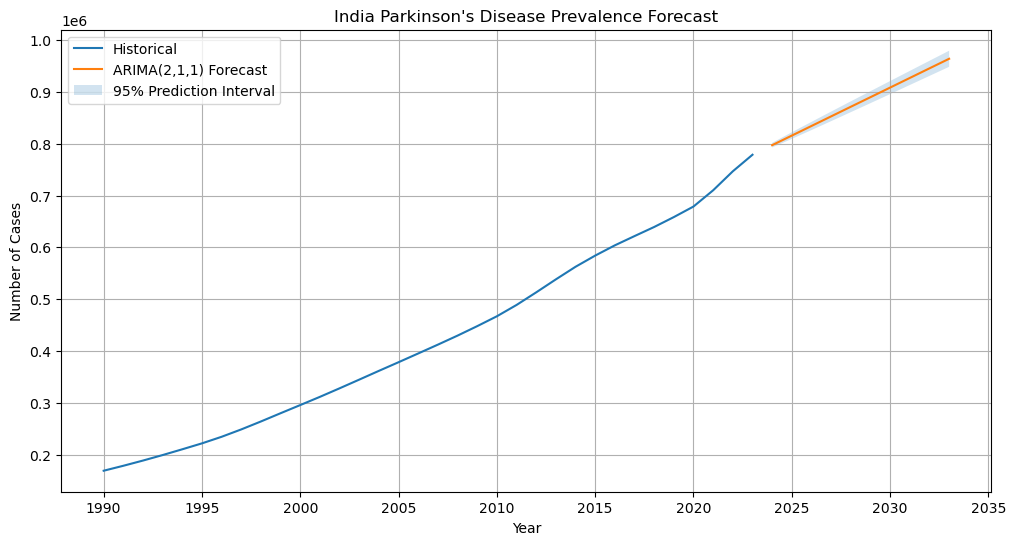

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    ts.index,
    ts["Parkinson_cases"],
    label="Historical"
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="ARIMA(2,1,1) Forecast"
)

plt.fill_between(
    forecast_mean.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title("India Parkinson's Disease Prevalence Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.legend()
plt.grid(True)
plt.show()

In [18]:
treatment_rate = 0.948

drug_demand_df = pd.DataFrame({
    "Year": forecast_mean.index.year,
    "Parkinson_cases": forecast_mean.values
})

drug_demand_df["Estimated_Levodopa_Patients"] = (
    drug_demand_df["Parkinson_cases"] * treatment_rate
)

print(drug_demand_df)

   Year  Parkinson_cases  Estimated_Levodopa_Patients
0  2024    797352.497067                755890.167220
1  2025    815892.328529                773465.927445
2  2026    834431.661723                791041.215313
3  2027    852970.844706                808616.360781
4  2028    871509.875714                826191.362177
5  2029    890048.754758                843766.219511
6  2030    908587.481838                861340.932783
7  2031    927126.056956                878915.501994
8  2032    945664.480113                896489.927147
9  2033    964202.751310                914064.208241


In [19]:
print(
    drug_demand_df[
        drug_demand_df["Year"].isin([2024, 2033])
    ]
)

   Year  Parkinson_cases  Estimated_Levodopa_Patients
0  2024    797352.497067                755890.167220
9  2033    964202.751310                914064.208241


In [20]:
tablets_per_day = 2

drug_demand_df["Annual_Tablets"] = (
    drug_demand_df["Estimated_Levodopa_Patients"]
    * tablets_per_day
    * 365
)

print(
    drug_demand_df[
        ["Year", "Estimated_Levodopa_Patients", "Annual_Tablets"]
    ]
)

   Year  Estimated_Levodopa_Patients  Annual_Tablets
0  2024                755890.167220    5.517998e+08
1  2025                773465.927445    5.646301e+08
2  2026                791041.215313    5.774601e+08
3  2027                808616.360781    5.902899e+08
4  2028                826191.362177    6.031197e+08
5  2029                843766.219511    6.159493e+08
6  2030                861340.932783    6.287789e+08
7  2031                878915.501994    6.416083e+08
8  2032                896489.927147    6.544376e+08
9  2033                914064.208241    6.672669e+08


In [21]:
price_per_tablet = 2.50

drug_demand_df["Estimated_Market_Value_Rs"] = (
    drug_demand_df["Annual_Tablets"] * price_per_tablet
)

drug_demand_df["Estimated_Market_Value_Crore"] = (
    drug_demand_df["Estimated_Market_Value_Rs"] / 1e7
)

print(
    drug_demand_df[
        ["Year",
         "Estimated_Levodopa_Patients",
         "Annual_Tablets",
         "Estimated_Market_Value_Crore"]
    ]
)

   Year  Estimated_Levodopa_Patients  Annual_Tablets  \
0  2024                755890.167220    5.517998e+08   
1  2025                773465.927445    5.646301e+08   
2  2026                791041.215313    5.774601e+08   
3  2027                808616.360781    5.902899e+08   
4  2028                826191.362177    6.031197e+08   
5  2029                843766.219511    6.159493e+08   
6  2030                861340.932783    6.287789e+08   
7  2031                878915.501994    6.416083e+08   
8  2032                896489.927147    6.544376e+08   
9  2033                914064.208241    6.672669e+08   

   Estimated_Market_Value_Crore  
0                    137.949956  
1                    141.157532  
2                    144.365022  
3                    147.572486  
4                    150.779924  
5                    153.987335  
6                    157.194720  
7                    160.402079  
8                    163.609412  
9                    166.816718  


In [22]:
scenarios = {
    "Low": {
        "treatment_rate": 0.85,
        "tablets_per_day": 1.5
    },
    "Base": {
        "treatment_rate": 0.948,
        "tablets_per_day": 2
    },
    "High": {
        "treatment_rate": 0.98,
        "tablets_per_day": 3
    }
}

price_per_tablet = 2.50

for scenario, assumptions in scenarios.items():

    patients = (
        forecast_mean *
        assumptions["treatment_rate"]
    )

    annual_tablets = (
        patients *
        assumptions["tablets_per_day"] *
        365
    )

    market_value_crore = (
        annual_tablets *
        price_per_tablet /
        1e7
    )

    print(
        scenario,
        "2033 market value:",
        round(market_value_crore.iloc[-1], 2),
        "crore"
    )

Low 2033 market value: 112.18 crore
Base 2033 market value: 166.82 crore
High 2033 market value: 258.67 crore


In [23]:
scenario_values = {}

for scenario, assumptions in scenarios.items():

    patients = (
        forecast_mean *
        assumptions["treatment_rate"]
    )

    annual_tablets = (
        patients *
        assumptions["tablets_per_day"] *
        365
    )

    market_value_crore = (
        annual_tablets *
        price_per_tablet /
        1e7
    )

    scenario_values[scenario] = market_value_crore

scenario_df = pd.DataFrame(
    scenario_values,
    index=forecast_mean.index.year
)

scenario_df.index.name = "Year"

print(scenario_df)

      Low  Base  High
Year                 
2024  NaN   NaN   NaN
2025  NaN   NaN   NaN
2026  NaN   NaN   NaN
2027  NaN   NaN   NaN
2028  NaN   NaN   NaN
2029  NaN   NaN   NaN
2030  NaN   NaN   NaN
2031  NaN   NaN   NaN
2032  NaN   NaN   NaN
2033  NaN   NaN   NaN


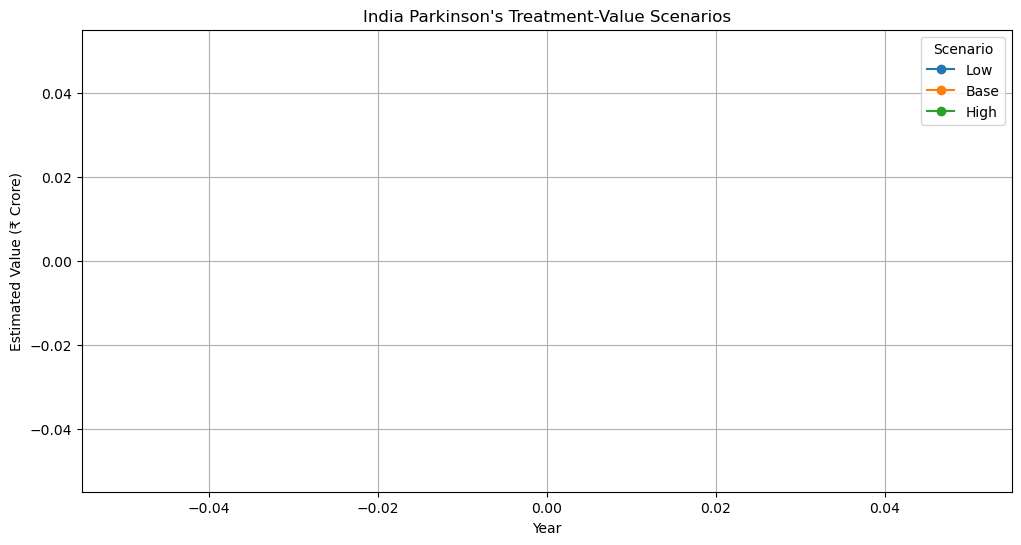

In [24]:
scenario_df.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("India Parkinson's Treatment-Value Scenarios")
plt.xlabel("Year")
plt.ylabel("Estimated Value (₹ Crore)")
plt.grid(True)
plt.legend(title="Scenario")

plt.show()

In [25]:
scenario_values = {}

for scenario, assumptions in scenarios.items():

    patients = forecast_mean * assumptions["treatment_rate"]

    annual_tablets = (
        patients *
        assumptions["tablets_per_day"] *
        365
    )

    market_value_crore = (
        annual_tablets *
        price_per_tablet / 1e7
    )

    scenario_values[scenario] = market_value_crore.values

scenario_df = pd.DataFrame(
    scenario_values,
    index=forecast_mean.index.year
)

scenario_df.index.name = "Year"

print(scenario_df)

             Low        Base        High
Year                                    
2024   92.766980  137.949956  213.909741
2025   94.923973  141.157532  218.883514
2026   97.080909  144.365022  223.857154
2027   99.237827  147.572486  228.830753
2028  101.394727  150.779924  233.804312
2029  103.551610  153.987335  238.777830
2030  105.708475  157.194720  243.751307
2031  107.865322  160.402079  248.724743
2032  110.022152  163.609412  253.698138
2033  112.178964  166.816718  258.671493


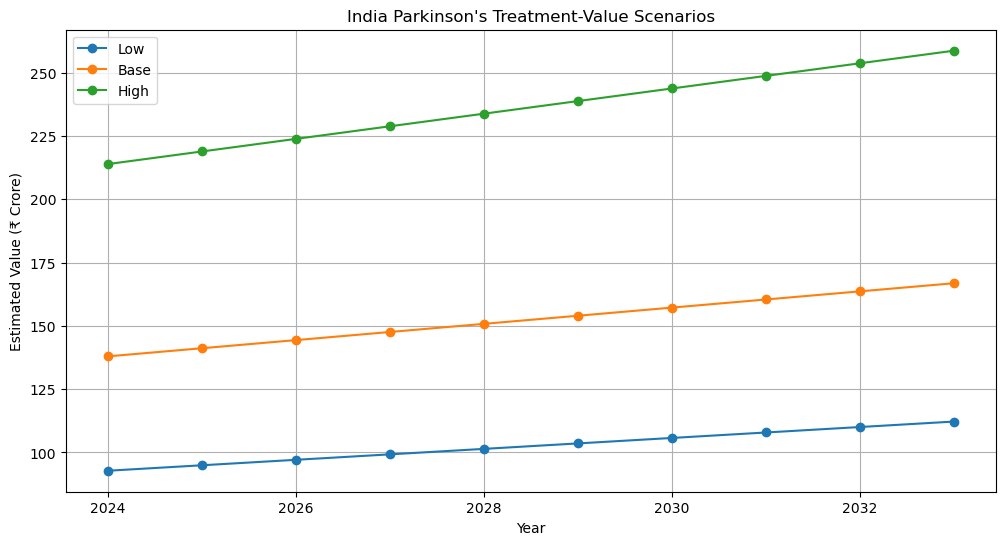

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(scenario_df.index, scenario_df["Low"], marker="o", label="Low")
plt.plot(scenario_df.index, scenario_df["Base"], marker="o", label="Base")
plt.plot(scenario_df.index, scenario_df["High"], marker="o", label="High")

plt.title("India Parkinson's Treatment-Value Scenarios")
plt.xlabel("Year")
plt.ylabel("Estimated Value (₹ Crore)")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Fit ARIMA(2,1,1) on training data
model = ARIMA(train["Parkinson_cases"], order=(2, 1, 1))
fitted_model = model.fit()

# Forecast the test period
test_forecast = fitted_model.forecast(steps=len(test))

# Metrics
mae = mean_absolute_error(test["Parkinson_cases"], test_forecast)

rmse = np.sqrt(
    mean_squared_error(test["Parkinson_cases"], test_forecast)
)

mape = np.mean(
    np.abs(
        (test["Parkinson_cases"] - test_forecast)
        / test["Parkinson_cases"]
    )
) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


MAE  : 25195.82
RMSE : 32441.36
MAPE : 3.37%


C:\Users\swarup karande\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


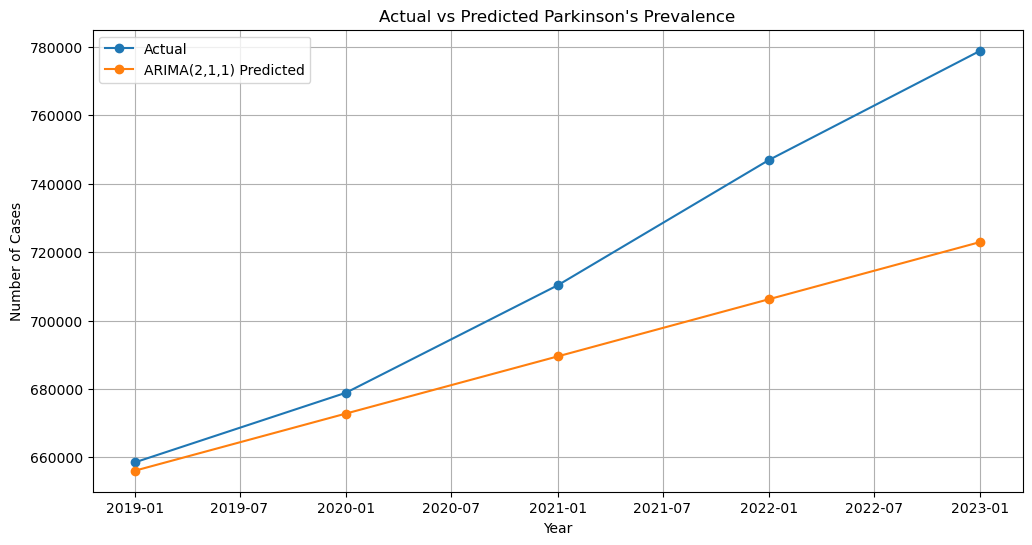

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    test.index,
    test["Parkinson_cases"],
    marker="o",
    label="Actual"
)

plt.plot(
    test.index,
    test_forecast,
    marker="o",
    label="ARIMA(2,1,1) Predicted"
)

plt.title("Actual vs Predicted Parkinson's Prevalence")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.legend()
plt.grid(True)

plt.show()